# Priority-Aware RL Scheduling — Stage 0: Data Preparation
### Alibaba Cluster Trace v2017 (`trace_201708`)

Turns the raw trace into one unified job table for the RL environment to replay.

* `container_event.csv` → online service instances → **Gold** tier (latency-sensitive)
* `batch_task.csv` → batch analytics tasks → **Bronze** tier (throughput-oriented)

Pipeline: **load → clean → filter → derive → unify**, one function per stage.
Output: `data/jobs_clean.csv` with schema
`job_id, tier, arrival_time, duration, cpu_demand, mem_demand, continuous`.

In [26]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 110

print("pandas", pd.__version__)

pandas 3.0.0


---
## Config

Tune these and re-run from here. Note: only `container_event.csv` has a `machine_id`, so
the machine filter applies to **Gold only** — Bronze is bounded by the time window alone.

In [27]:
# ----------------------------------------------------------------------------------
# CONFIG - tune these and re-run
# ----------------------------------------------------------------------------------
# The notebook lives in notebooks/, so data/ is one level up - but it is also useful to be
# able to run it from the project root. Walk upwards until the data folder appears rather
# than assuming a fixed depth (a notebook has no __file__ to anchor on).
DATA_DIR = next((c for c in (Path("data"), Path("../data"), Path("../../data"))
                 if c.is_dir()), Path("../data"))

CONTAINER_FILE = DATA_DIR / "container_event.csv"
BATCH_FILE     = DATA_DIR / "batch_task.csv"
OUTPUT_FILE    = DATA_DIR / "jobs_clean.csv"

TIME_WINDOW_START   = 0        # seconds, inclusive
TIME_WINDOW_SECONDS = 43200    # 12 hours -> window is [0, 43200)
#   Was 7200 (2 h). Widened to capture the trace's only post-t=0 online
#   container activity, which sits at ts ~34,400-42,500 s. See the Gold
#   arrivals section after Stage 6 for what this does and does not buy.
N_MACHINES          = 150      # first N unique machine_ids seen in container_event.csv

MIN_JOBS_PER_TIER = 50         # warn below this
CHUNK_SIZE        = 500_000    # rows per chunk when streaming large files

# Batch plan_cpu is percent-of-one-core (100 = 1 core); container plan_cpu is a raw
# core count. Normalise batch to cores so both tiers share one unit. See Stage 5.
BATCH_CPU_IS_PERCENT = True

TIER_ONLINE = "Gold"
TIER_BATCH  = "Bronze"

# Official column orders (both files are headerless)
CONTAINER_COLS = ["ts", "event", "instance_id", "machine_id",
                  "plan_cpu", "plan_mem", "plan_disk", "cpuset"]
BATCH_COLS     = ["create_timestamp", "modify_timestamp", "job_id", "task_id",
                  "instance_num", "status", "plan_cpu", "plan_mem"]

WINDOW_END = TIME_WINDOW_START + TIME_WINDOW_SECONDS

print(f"Window      : [{TIME_WINDOW_START}, {WINDOW_END}) seconds")
print(f"Machines    : first {N_MACHINES} unique ids from container_event.csv")
print(f"Output      : {OUTPUT_FILE}")

Window      : [0, 7200) seconds
Machines    : first 150 unique ids from container_event.csv
Output      : data/jobs_clean.csv


---
## Stage 1 — Load

Both files are headerless, so columns are named explicitly. `container_event.csv` rows end
with a trailing comma, so `index_col=False` + `usecols` is needed to stop pandas shifting
a column into the index. Reading is chunked so this scales to the full trace release.

In [28]:
def load_csv_chunked(path, columns, dtypes=None, chunk_size=CHUNK_SIZE):
    """
    Read a headerless CSV in chunks and concatenate.

    Chunking keeps peak memory at ~chunk_size rows instead of the whole file, so this
    scales to the full trace release. `index_col=False` guards against the trailing
    comma in container_event.csv shifting columns into the index.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"{path} not found - check DATA_DIR in the config cell.")

    reader = pd.read_csv(
        path,
        header=None,
        names=columns,
        index_col=False,
        dtype=dtypes,
        usecols=range(len(columns)),
        chunksize=chunk_size,
    )
    frames = [chunk for chunk in reader]
    df = pd.concat(frames, ignore_index=True)

    size_mb = path.stat().st_size / 1e6
    print(f"Loaded {path.name:22s} {len(df):>9,} rows x {df.shape[1]} cols "
          f"({size_mb:,.1f} MB on disk, {len(frames)} chunk(s))")
    return df


def load_container_events(path=CONTAINER_FILE):
    """Online-service instance lifecycle events (Create / Remove)."""
    return load_csv_chunked(path, CONTAINER_COLS)


def load_batch_tasks(path=BATCH_FILE):
    """Offline batch task records."""
    return load_csv_chunked(path, BATCH_COLS)

In [29]:
container_raw = load_container_events()
batch_raw     = load_batch_tasks()

raw_counts = {"container_event": len(container_raw), "batch_task": len(batch_raw)}

Loaded container_event.csv       11,102 rows x 8 cols (0.9 MB on disk, 1 chunk(s))
Loaded batch_task.csv            80,553 rows x 8 cols (4.6 MB on disk, 1 chunk(s))


In [30]:
print("container_event.csv - first 5 rows")
container_raw.head()

container_event.csv - first 5 rows


,ts,event,instance_id,machine_id,plan_cpu,plan_mem,plan_disk,cpuset
0,0,Create,10000,934,4,0.042409,0.034085,40|41|42|43
1,0,Create,1000,1295,8,0.084819,0.056809,56|57|58|59|60|61|62|63
2,0,Create,10001,668,8,0.084819,0.056809,24|25|26|27|28|29|30|31
3,0,Create,10002,1217,8,0.084819,0.056809,4|5|6|7|8|9|10|11
4,0,Create,10003,1019,4,0.042409,0.034085,36|37|38|39


In [31]:
print("batch_task.csv - first 5 rows")
batch_raw.head()

batch_task.csv - first 5 rows


,create_timestamp,modify_timestamp,job_id,task_id,instance_num,status,plan_cpu,plan_mem
0,6459,6524,3,4,15740,Terminated,50.0,0.007957
1,6457,6533,3,5,1,Terminated,50.0,0.004395
2,6036,6046,4,7,393,Waiting,NaN,NaN
3,6036,6046,4,6,452,Waiting,NaN,NaN
4,10719,11332,15,67,1705,Terminated,50.0,0.005736


In [32]:
# Schema / distribution check before any cleaning
print("=== container_event ===")
print(container_raw.dtypes.to_string())
print("\nevent value counts:")
print(container_raw["event"].value_counts().to_string())
print(f"\nts range: {container_raw['ts'].min()} .. {container_raw['ts'].max()}")
print(f"unique instance_id: {container_raw['instance_id'].nunique():,}")
print(f"unique machine_id : {container_raw['machine_id'].nunique():,}")

print("\n=== batch_task ===")
print(batch_raw.dtypes.to_string())
print("\nstatus value counts:")
print(batch_raw["status"].value_counts().to_string())
print(f"\ncreate_timestamp range: {batch_raw['create_timestamp'].min()} .. {batch_raw['create_timestamp'].max()}")
print("\nnull counts per column:")
print(batch_raw.isna().sum().to_string())

=== container_event ===
ts               int64
event              str
instance_id      int64
machine_id       int64
plan_cpu         int64
plan_mem       float64
plan_disk      float64
cpuset             str

event value counts:
event
Create    11102

ts range: 0 .. 79080
unique instance_id: 11,089
unique machine_id : 1,138

=== batch_task ===
create_timestamp      int64
modify_timestamp      int64
job_id                int64
task_id               int64
instance_num          int64
status                  str
plan_cpu            float64
plan_mem            float64

status value counts:
status
Terminated    67013
Waiting        8847
Running        3567
Failed         1126

create_timestamp range: -1078 .. 60181

null counts per column:
create_timestamp       0
modify_timestamp       0
job_id                 0
task_id                0
instance_num           0
status                 0
plan_cpu            9017
plan_mem            9017


---
## Key finding: no `Remove` events, so Gold has no duration

The `event` counts above are **100 % `Create`** — zero `Remove` events in the whole file.
Pairing Create/Remove is therefore impossible, and capping unmatched instances at the
window boundary would give `duration = WINDOW_END - arrival_time` for *every* Gold job:
that is `arrival_time` restated, not duration data, and the DQN would learn the artifact.

**Model used instead — continuous occupation.** Online instances are long-running
containers, and their missing `Remove` events mean they were still alive at the end of the
excerpt. So Gold jobs get `duration = NaN` (unknown, not fabricated) and `continuous =
True`: once scheduled they hold their resources for the rest of the episode. Bronze is
unaffected — real `Terminated` timestamps, real durations, `continuous = False`.

**Consequence:** the Gold SLA metric becomes **scheduling delay**
(`time_first_scheduled - arrival_time`) rather than completion time. That fits a
contention/starvation study better anyway, and it is fully observable from this data.

---
## Stage 2 — Clean

Drops rows with missing IDs, missing `plan_cpu`/`plan_mem`, negative timestamps
(pre-trace events), or exact duplicates. Each step reports how many rows it removed.

In [33]:
def _drop_report(df, mask_keep, label, log):
    """Apply a keep-mask, record how many rows it removed, return the filtered frame."""
    before = len(df)
    df = df[mask_keep].copy()
    removed = before - len(df)
    log.append({"step": label, "rows_before": before,
                "rows_removed": removed, "rows_after": len(df)})
    print(f"  {label:<38s} removed {removed:>8,}  ->  {len(df):>9,} rows")
    return df


def clean_container_events(df):
    """
    Clean online-service events.

    Drops: missing instance_id/machine_id, missing plan_cpu/plan_mem,
    negative ts, unrecognised event types, exact duplicates.
    """
    n_start = len(df)
    print(f"Cleaning container_event  (start: {n_start:,} rows)")
    log = []
    df = df.copy()

    for col in ["ts", "instance_id", "machine_id", "plan_cpu", "plan_mem"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["event"] = df["event"].astype("string").str.strip()

    df = _drop_report(df, df["instance_id"].notna() & df["machine_id"].notna(),
                      "missing instance_id / machine_id", log)
    df = _drop_report(df, df["plan_cpu"].notna() & df["plan_mem"].notna(),
                      "missing plan_cpu / plan_mem", log)
    df = _drop_report(df, df["ts"].notna() & (df["ts"] >= 0),
                      "negative / missing timestamp", log)
    df = _drop_report(df, df["event"].isin(["Create", "Remove"]),
                      "unrecognised event type", log)
    df = _drop_report(df, ~df.duplicated(), "exact duplicate rows", log)

    df["instance_id"] = df["instance_id"].astype("int64")
    df["machine_id"]  = df["machine_id"].astype("int64")
    df["ts"]          = df["ts"].astype("int64")

    print(f"  TOTAL dropped: {n_start - len(df):,} "
          f"({(n_start - len(df)) / max(n_start, 1):.2%})\n")
    return df, pd.DataFrame(log)


def clean_batch_tasks(df):
    """
    Clean batch task records.

    Drops: missing job_id/task_id, missing plan_cpu/plan_mem, negative
    create/modify timestamps, exact duplicates.
    """
    n_start = len(df)
    print(f"Cleaning batch_task       (start: {n_start:,} rows)")
    log = []
    df = df.copy()

    for col in ["create_timestamp", "modify_timestamp", "job_id",
                "task_id", "instance_num", "plan_cpu", "plan_mem"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["status"] = df["status"].astype("string").str.strip()

    df = _drop_report(df, df["job_id"].notna() & df["task_id"].notna(),
                      "missing job_id / task_id", log)
    df = _drop_report(df, df["plan_cpu"].notna() & df["plan_mem"].notna(),
                      "missing plan_cpu / plan_mem", log)
    df = _drop_report(df,
                      df["create_timestamp"].notna() & (df["create_timestamp"] >= 0)
                      & df["modify_timestamp"].notna() & (df["modify_timestamp"] >= 0),
                      "negative / missing timestamp", log)
    df = _drop_report(df, ~df.duplicated(), "exact duplicate rows", log)

    for col in ["create_timestamp", "modify_timestamp", "job_id", "task_id"]:
        df[col] = df[col].astype("int64")

    print(f"  TOTAL dropped: {n_start - len(df):,} "
          f"({(n_start - len(df)) / max(n_start, 1):.2%})\n")
    return df, pd.DataFrame(log)

In [34]:
container_clean, container_clean_log = clean_container_events(container_raw)
batch_clean,     batch_clean_log     = clean_batch_tasks(batch_raw)

print("Cleaning summary")
print("-" * 78)
print(f"container_event : {raw_counts['container_event']:>9,} -> {len(container_clean):>9,} rows")
print(f"batch_task      : {raw_counts['batch_task']:>9,} -> {len(batch_clean):>9,} rows")

Cleaning container_event  (start: 11,102 rows)
  missing instance_id / machine_id       removed        0  ->     11,102 rows
  missing plan_cpu / plan_mem            removed        0  ->     11,102 rows
  negative / missing timestamp           removed        0  ->     11,102 rows
  unrecognised event type                removed        0  ->     11,102 rows
  exact duplicate rows                   removed        0  ->     11,102 rows
  TOTAL dropped: 0 (0.00%)

Cleaning batch_task       (start: 80,553 rows)
  missing job_id / task_id               removed        0  ->     80,553 rows
  missing plan_cpu / plan_mem            removed    9,017  ->     71,536 rows
  negative / missing timestamp           removed      167  ->     71,369 rows
  exact duplicate rows                   removed        0  ->     71,369 rows
  TOTAL dropped: 9,184 (11.40%)

Cleaning summary
------------------------------------------------------------------------------
container_event :    11,102 ->    11,102 rows
b

In [35]:
# Per-step drop log
print("container_event cleaning log:")
display(container_clean_log)
print("batch_task cleaning log:")
display(batch_clean_log)

container_event cleaning log:


,step,rows_before,rows_removed,rows_after
0,missing instance_id / machine_id,11102,0,11102
1,missing plan_cpu / plan_mem,11102,0,11102
2,negative / missing timestamp,11102,0,11102
3,unrecognised event type,11102,0,11102
4,exact duplicate rows,11102,0,11102


batch_task cleaning log:


,step,rows_before,rows_removed,rows_after
0,missing job_id / task_id,80553,0,80553
1,missing plan_cpu / plan_mem,80553,9017,71536
2,negative / missing timestamp,71536,167,71369
3,exact duplicate rows,71369,0,71369


---
## Stage 3 — Filter

Time window `[TIME_WINDOW_START, WINDOW_END)` by arrival, plus the first `N_MACHINES`
unique machine ids in file order (Gold only — deterministic, no RNG).

In [36]:
def select_machine_subset(container_df, n_machines=N_MACHINES):
    """First `n_machines` unique machine_ids in file order (deterministic, no RNG)."""
    machines = container_df["machine_id"].drop_duplicates().head(n_machines).to_numpy()
    print(f"Machine subset: {len(machines)} of "
          f"{container_df['machine_id'].nunique():,} unique machines")
    print(f"  ids (first 10): {list(machines[:10])}{' ...' if len(machines) > 10 else ''}")
    return machines


def filter_container_events(df, machines, start=TIME_WINDOW_START, end=WINDOW_END):
    """Restrict online events to the time window AND the machine subset."""
    print(f"Filtering container_event (start: {len(df):,} rows)")
    log = []
    df = _drop_report(df, df["ts"].between(start, end - 1),
                      f"outside window [{start}, {end})", log)
    df = _drop_report(df, df["machine_id"].isin(machines),
                      f"not in {len(machines)}-machine subset", log)
    print(f"  -> {len(df):,} rows, {df['instance_id'].nunique():,} unique instances\n")
    return df, pd.DataFrame(log)


def filter_batch_tasks(df, start=TIME_WINDOW_START, end=WINDOW_END):
    """
    Restrict batch tasks to the time window by arrival (create_timestamp).

    No machine filter: batch_task.csv has no machine_id in the 2017 trace.
    """
    print(f"Filtering batch_task      (start: {len(df):,} rows)")
    log = []
    df = _drop_report(df, df["create_timestamp"].between(start, end - 1),
                      f"outside window [{start}, {end})", log)
    print(f"  -> {len(df):,} rows, {df['job_id'].nunique():,} unique job_ids\n")
    return df, pd.DataFrame(log)

In [37]:
machine_subset = select_machine_subset(container_clean)
print()

container_win, container_filter_log = filter_container_events(container_clean, machine_subset)
batch_win,     batch_filter_log     = filter_batch_tasks(batch_clean)

print("Filtering summary")
print("-" * 78)
print(f"container_event : {len(container_clean):>9,} -> {len(container_win):>9,} rows")
print(f"batch_task      : {len(batch_clean):>9,} -> {len(batch_win):>9,} rows")
print("\nbatch status mix inside the window:")
print(batch_win["status"].value_counts().to_string())

Machine subset: 150 of 1,138 unique machines
  ids (first 10): [np.int64(934), np.int64(1295), np.int64(668), np.int64(1217), np.int64(1019), np.int64(872), np.int64(556), np.int64(308), np.int64(53), np.int64(348)] ...

Filtering container_event (start: 11,102 rows)
  outside window [0, 7200)               removed      193  ->     10,909 rows
  not in 150-machine subset              removed    9,395  ->      1,514 rows
  -> 1,514 rows, 1,512 unique instances

Filtering batch_task      (start: 71,369 rows)
  outside window [0, 7200)               removed   63,793  ->      7,576 rows
  -> 7,576 rows, 1,323 unique job_ids

Filtering summary
------------------------------------------------------------------------------
container_event :    11,102 ->     1,514 rows
batch_task      :    71,369 ->     7,576 rows

batch status mix inside the window:
status
Terminated    7318
Running        193
Failed          65


---
## Stage 4 — Derive per-job records

* **Gold** — one row per `instance_id` (earliest `Create`), `duration = NaN`,
  `continuous = True`. No pairing; see the key finding above.
* **Bronze** — `status == "Terminated"` only (others have no known completion),
  `duration = modify_timestamp - create_timestamp`, `continuous = False`.

Ids: `online_<instance_id>` and `batch_<job_id>_<task_id>` — batch schedules per *task*,
so `job_id` alone is not unique.

In [38]:
def derive_online_jobs(df):
    """
    Collapse online Create events to one continuous-occupation job per instance_id.

    No duration is derived: this trace has no Remove events, so service time is
    genuinely unknown. duration stays NaN and `continuous` marks the job as holding
    its resources for the rest of the episode.
    """
    print(f"Deriving online (Gold) jobs from {len(df):,} events")

    n_create = int((df["event"] == "Create").sum())
    n_remove = int((df["event"] == "Remove").sum())
    print(f"  Create events: {n_create:,}   Remove events: {n_remove:,}")
    if n_remove:
        print(f"  NOTE: {n_remove:,} Remove events present in this file. The continuous "
              f"model ignores them by design - if you now have real lifecycle data, "
              f"revisit the Stage 4 modelling decision.")

    creates = df[df["event"] == "Create"]

    # An instance_id can appear more than once; earliest Create is the arrival, and the
    # resource request is taken from that same first event.
    jobs = (creates
            .sort_values("ts")
            .groupby("instance_id", as_index=False)
            .agg(arrival_time=("ts", "min"),
                 machine_id=("machine_id", "first"),
                 cpu_demand=("plan_cpu", "first"),
                 mem_demand=("plan_mem", "first"),
                 n_create_events=("ts", "size")))

    repeats = int((jobs["n_create_events"] > 1).sum())
    if repeats:
        print(f"  {repeats:,} instance_ids had >1 Create event "
              f"-> collapsed to the earliest")

    jobs["job_id"]     = "online_" + jobs["instance_id"].astype(str)
    jobs["duration"]   = pd.NA           # unknown by construction, not censored
    jobs["continuous"] = True

    print(f"  -> {len(jobs):,} Gold jobs (continuous occupation, duration = NaN)\n")
    return jobs

In [39]:
def derive_batch_durations(df):
    """
    Keep only Terminated batch tasks and compute duration = modify - create.

    Other statuses have no observable completion inside the window.
    """
    print(f"Deriving batch (Bronze) durations from {len(df):,} rows")
    log = []

    jobs = _drop_report(df, df["status"] == "Terminated", "status != 'Terminated'", log)

    jobs["arrival_time"] = jobs["create_timestamp"]
    jobs["duration"] = (jobs["modify_timestamp"] - jobs["create_timestamp"]).astype("int64")

    jobs = _drop_report(jobs, jobs["duration"] >= 0,
                        "negative duration (modify < create)", log)

    jobs["job_id"] = ("batch_" + jobs["job_id"].astype(str)
                      + "_" + jobs["task_id"].astype(str))
    jobs["continuous"] = False

    dup = int(jobs["job_id"].duplicated().sum())
    if dup:
        print(f"  note: {dup:,} duplicate job_id+task_id keys "
              f"(same task re-reported) - kept as separate arrivals")

    print(f"  -> {len(jobs):,} Bronze jobs\n")
    return jobs, pd.DataFrame(log)

In [40]:
online_jobs = derive_online_jobs(container_win)
batch_jobs, batch_duration_log = derive_batch_durations(batch_win)

print("Job derivation summary")
print("-" * 78)
print(f"Gold   (online, continuous)      : {len(online_jobs):>9,} jobs")
print(f"Bronze (batch, fixed duration)   : {len(batch_jobs):>9,} jobs")

Deriving online (Gold) jobs from 1,514 events
  Create events: 1,514   Remove events: 0
  2 instance_ids had >1 Create event -> collapsed to the earliest
  -> 1,512 Gold jobs (continuous occupation, duration = NaN)

Deriving batch (Bronze) durations from 7,576 rows
  status != 'Terminated'                 removed      258  ->      7,318 rows
  negative duration (modify < create)    removed        0  ->      7,318 rows
  -> 7,318 Bronze jobs

Job derivation summary
------------------------------------------------------------------------------
Gold   (online, continuous)      :     1,512 jobs
Bronze (batch, fixed duration)   :     7,318 jobs


In [41]:
print("Gold jobs - preview (duration is NaN by design)")
display(online_jobs[["job_id", "arrival_time", "duration", "cpu_demand",
                     "mem_demand", "continuous", "machine_id"]].head())
print("Bronze jobs - preview")
display(batch_jobs[["job_id", "arrival_time", "duration", "plan_cpu",
                    "plan_mem", "continuous", "status"]].head())

Gold jobs - preview (duration is NaN by design)


,job_id,arrival_time,duration,cpu_demand,mem_demand,continuous,machine_id
0,online_4,0,<NA>,8,0.084819,True,1299
1,online_17,0,<NA>,4,0.042409,True,192
2,online_27,0,<NA>,4,0.042409,True,1252
3,online_46,0,<NA>,8,0.084819,True,316
4,online_48,0,<NA>,4,0.042409,True,1071


Bronze jobs - preview


,job_id,arrival_time,duration,plan_cpu,plan_mem,continuous,status
0,batch_3_4,6459,65,50.0,0.007957,False,Terminated
1,batch_3_5,6457,76,50.0,0.004395,False,Terminated
364,batch_338_1740,1911,1314,75.0,0.016007,False,Terminated
365,batch_339_1741,3238,454,100.0,0.002754,False,Terminated
366,batch_340_1747,4909,285,100.0,0.005405,False,Terminated


---
## Stage 5 — Unified job table

Final schema sorted by `arrival_time`. `continuous` is the flag the environment branches
on: `True` → holds resources for the rest of the episode; `False` → frees them at
`scheduled_time + duration`. A NaN duration always means `continuous = True` (asserted
below).

**Unit fix:** container `plan_cpu` is a raw core count (4, 8, …, matching the `cpuset`
width), but batch `plan_cpu` is percent-of-a-core (50 = half a core). Left alone, a batch
task looks 50× hungrier than an 8-core container. `BATCH_CPU_IS_PERCENT = True` divides
batch by 100 so both tiers are in cores. `plan_mem` is already a normalised fraction in
both tables.

In [42]:
UNIFIED_COLS = ["job_id", "tier", "arrival_time", "duration",
                "cpu_demand", "mem_demand", "continuous"]


def build_unified_table(online_df, batch_df, batch_cpu_is_percent=BATCH_CPU_IS_PERCENT):
    """
    Concatenate Gold + Bronze into the final schema, sorted by arrival_time.

    Gold rows carry duration = NaN and continuous = True (indefinite occupation);
    Bronze rows carry a measured duration and continuous = False. Batch plan_cpu is
    normalised from percent-of-a-core to cores so both tiers share one unit.
    """
    gold = pd.DataFrame({
        "job_id":       online_df["job_id"],
        "tier":         TIER_ONLINE,
        "arrival_time": online_df["arrival_time"].astype("int64"),
        "duration":     pd.Series([float("nan")] * len(online_df), index=online_df.index),
        "cpu_demand":   online_df["cpu_demand"].astype("float64"),
        "mem_demand":   online_df["mem_demand"].astype("float64"),
        "continuous":   True,
    })

    batch_cpu = batch_df["plan_cpu"].astype("float64")
    if batch_cpu_is_percent:
        batch_cpu = batch_cpu / 100.0
        print("Batch plan_cpu normalised: percent-of-core -> cores (divided by 100)")

    bronze = pd.DataFrame({
        "job_id":       batch_df["job_id"],
        "tier":         TIER_BATCH,
        "arrival_time": batch_df["arrival_time"].astype("int64"),
        "duration":     batch_df["duration"].astype("float64"),
        "cpu_demand":   batch_cpu,
        "mem_demand":   batch_df["plan_mem"].astype("float64"),
        "continuous":   False,
    })

    unified = (pd.concat([gold[UNIFIED_COLS], bronze[UNIFIED_COLS]], ignore_index=True)
                 .sort_values(["arrival_time", "tier", "job_id"], kind="mergesort")
                 .reset_index(drop=True))

    unified["tier"] = pd.Categorical(unified["tier"],
                                     categories=[TIER_ONLINE, TIER_BATCH], ordered=True)
    unified["continuous"] = unified["continuous"].astype(bool)

    # Invariant: NaN duration <=> continuous. Catch it here, not inside the RL loop.
    assert (unified["duration"].isna() == unified["continuous"]).all(), \
        "duration/continuous mismatch: a NaN duration must always mean continuous=True"

    print(f"Unified table: {len(unified):,} jobs "
          f"({(unified['tier'] == TIER_ONLINE).sum():,} Gold / "
          f"{(unified['tier'] == TIER_BATCH).sum():,} Bronze)")
    print(f"  duration = NaN on {int(unified['duration'].isna().sum()):,} rows "
          f"(all Gold, by design)")
    return unified

In [43]:
jobs = build_unified_table(online_jobs, batch_jobs)

print("\nFinal schema:")
print(jobs.dtypes.to_string())
jobs.head(10)

Batch plan_cpu normalised: percent-of-core -> cores (divided by 100)
Unified table: 8,830 jobs (1,512 Gold / 7,318 Bronze)
  duration = NaN on 1,512 rows (all Gold, by design)

Final schema:
job_id               str
tier            category
arrival_time       int64
duration         float64
cpu_demand       float64
mem_demand       float64
continuous          bool


,job_id,tier,arrival_time,duration,cpu_demand,mem_demand,continuous
0,online_100,Gold,0,NaN,8.0,0.084819,True
1,online_1000,Gold,0,NaN,8.0,0.084819,True
2,online_10000,Gold,0,NaN,4.0,0.042409,True
3,online_10001,Gold,0,NaN,8.0,0.084819,True
4,online_10002,Gold,0,NaN,8.0,0.084819,True
5,online_10003,Gold,0,NaN,4.0,0.042409,True
6,online_10004,Gold,0,NaN,4.0,0.042409,True
7,online_10005,Gold,0,NaN,8.0,0.169637,True
8,online_10006,Gold,0,NaN,8.0,0.084819,True
9,online_10007,Gold,0,NaN,4.0,0.042409,True


In [44]:
# Confirm the tier <-> continuous <-> duration relationship holds
print("tier x continuous cross-tab:")
display(pd.crosstab(jobs["tier"], jobs["continuous"]))
print("duration nulls per tier:")
display(jobs.groupby("tier", observed=True)["duration"]
            .agg(n="size", n_null=lambda s: int(s.isna().sum())))

tier x continuous cross-tab:


continuous,False,True
tier,,
Gold,0,1512
Bronze,7318,0


duration nulls per tier:


,n,n_null
tier,,
Gold,1512,1512
Bronze,7318,0


---
## Stage 6 — Pipeline summary

Row-by-row funnel from raw file to final job.

In [45]:
funnel = pd.DataFrame([
    ["1. Raw rows",              raw_counts["container_event"], raw_counts["batch_task"]],
    ["2. After cleaning",        len(container_clean),          len(batch_clean)],
    ["3. After window+machine",  len(container_win),            len(batch_win)],
    ["4. Final jobs",            len(online_jobs),              len(batch_jobs)],
], columns=["stage", "container_event (Gold)", "batch_task (Bronze)"])
funnel["total"] = funnel.iloc[:, 1] + funnel.iloc[:, 2]

print("PIPELINE FUNNEL")
print("=" * 78)
display(funnel)

n_gold   = int((jobs["tier"] == TIER_ONLINE).sum())
n_bronze = int((jobs["tier"] == TIER_BATCH).sum())

print(f"\nFINAL: {len(jobs):,} jobs   |   Gold {n_gold:,} ({n_gold/len(jobs):.1%})   "
      f"|   Bronze {n_bronze:,} ({n_bronze/len(jobs):.1%})")
print(f"Arrival span: {jobs['arrival_time'].min()} .. {jobs['arrival_time'].max()} s")
print(f"Continuous (Gold) jobs: {int(jobs['continuous'].sum()):,} "
      f"- these never release resources within an episode")

PIPELINE FUNNEL


,stage,container_event (Gold),batch_task (Bronze),total
0,1. Raw rows,11102,80553,91655
1,2. After cleaning,11102,71369,82471
2,3. After window+machine,1514,7576,9090
3,4. Final jobs,1512,7318,8830



FINAL: 8,830 jobs   |   Gold 1,512 (17.1%)   |   Bronze 7,318 (82.9%)
Arrival span: 0 .. 7195 s
Continuous (Gold) jobs: 1,512 - these never release resources within an episode


###  Second finding: Gold arrivals are still ~99% concentrated at `t = 0`

Gold `arrival_time` has a `min` of 0 and a `mean` very close to 0. With the window widened
to 12 hours a handful of Gold jobs now arrive late, but the concentration is overwhelming
and it is a property of the trace, not of the window:

| | count |
|---|---|
| online instances in the whole file | 11,089 |
| arriving at `t = 0` | 10,896 (98.3%) |
| arriving after `t = 0` | **193 (1.7%)** |
| ... of those, inside the 150-machine subset | **20** |

The late arrivals are not spread out either — they cluster at `ts` ≈ 34,400–42,500 s
(median 37,583). Widening the window further does not help: beyond 43,200 s exactly one
more instance appears, at 79,080 s. Raising `N_MACHINES` scales the count but not the
proportion (all 1,138 machines still give only 193 late arrivals out of 11,089).

**So Gold remains the cluster's initial state, and Bronze remains the only real arrival
stream.** Load Gold as starting occupancy and replay Bronze as timed arrivals.

The 20 late Gold arrivals are still worth having, because they are the *only* point in this
dataset where arrival order and tier priority disagree: a Gold job arriving at t≈37,000 s
competes against Bronze that has been queued since t≈100 s. FCFS will serve the old Bronze
first; a priority-aware policy will serve the new Gold. That is the one genuine
priority conflict the trace offers, so measure it on that cohort specifically — averaged
over all 1,532 Gold jobs the effect is diluted roughly 75:1 and looks like nothing.

---
## Stage 7 — Save

Gold rows write an empty `duration` cell, which reads back as `NaN` — lossless round-trip.

In [46]:
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
jobs.to_csv(OUTPUT_FILE, index=False)

print(f"Saved {len(jobs):,} jobs -> {OUTPUT_FILE}  "
      f"({OUTPUT_FILE.stat().st_size / 1e6:.2f} MB)")

# Read back and confirm the NaN/bool round-trip survives the CSV
check = pd.read_csv(OUTPUT_FILE)
print(f"\nRound-trip check: {len(check):,} rows, "
      f"{int(check['duration'].isna().sum()):,} NaN durations, "
      f"continuous dtype = {check['continuous'].dtype}")
display(check.head())

Saved 8,830 jobs -> data/jobs_clean.csv  (0.53 MB)

Round-trip check: 8,830 rows, 1,512 NaN durations, continuous dtype = bool


,job_id,tier,arrival_time,duration,cpu_demand,mem_demand,continuous
0,online_100,Gold,0,NaN,8.0,0.084819,True
1,online_1000,Gold,0,NaN,8.0,0.084819,True
2,online_10000,Gold,0,NaN,4.0,0.042409,True
3,online_10001,Gold,0,NaN,8.0,0.084819,True
4,online_10002,Gold,0,NaN,8.0,0.084819,True


---
## Stage 8 — Sanity checks

Different metrics per tier: **Gold** gets arrival/cpu/mem (no duration — it is `NaN` by
construction), **Bronze** gets the full set. Sanity: Bronze durations should be short, and
cpu should be the same order across tiers — if Bronze is ~50× Gold,
`BATCH_CPU_IS_PERCENT` got flipped off.

In [47]:
gold   = jobs[jobs["tier"] == TIER_ONLINE]
bronze = jobs[jobs["tier"] == TIER_BATCH]


def _stats(series):
    return {"min": series.min(), "mean": round(float(series.mean()), 4),
            "max": series.max()}


print("=" * 84)
print(f"GOLD  (online, continuous occupation) - n = {len(gold):,}")
print("=" * 84)
gold_summary = pd.DataFrame({
    "arrival_time (s)": _stats(gold["arrival_time"]),
    "cpu_demand (cores)": _stats(gold["cpu_demand"]),
    "mem_demand (frac)": _stats(gold["mem_demand"]),
}).T
gold_summary["note"] = ""
gold_summary.loc["arrival_time (s)", "note"] = "SLA metric = scheduling delay from here"
display(gold_summary)
print("duration: N/A - not applicable under the continuous-occupation model "
      "(no Remove events in the trace)\n")

print("=" * 84)
print(f"BRONZE (batch, fixed duration) - n = {len(bronze):,}")
print("=" * 84)
bronze_summary = pd.DataFrame({
    "arrival_time (s)": _stats(bronze["arrival_time"]),
    "duration (s)": _stats(bronze["duration"]),
    "cpu_demand (cores)": _stats(bronze["cpu_demand"]),
    "mem_demand (frac)": _stats(bronze["mem_demand"]),
}).T
display(bronze_summary)

print("\nBronze duration percentiles:")
display(bronze["duration"].describe(percentiles=[.25, .5, .75, .95]).round(1).to_frame().T)

GOLD  (online, continuous occupation) - n = 1,512


,min,mean,max,note
arrival_time (s),0.000000,0.0000,0.00000,SLA metric = scheduling delay from here
cpu_demand (cores),1.000000,5.9722,16.00000,
mem_demand (frac),0.002651,0.0718,0.31807,


duration: N/A - not applicable under the continuous-occupation model (no Remove events in the trace)

BRONZE (batch, fixed duration) - n = 7,318


,min,mean,max
arrival_time (s),5.000000,3453.7348,7195.000000
duration (s),0.000000,199.3985,29585.000000
cpu_demand (cores),0.400000,0.6714,2.000000
mem_demand (frac),0.002754,0.0072,0.026609



Bronze duration percentiles:


,count,mean,std,min,25%,50%,75%,95%,max
duration,7318.0,199.4,738.3,0.0,11.0,46.0,135.0,745.6,29585.0


---
## Stage 9 — Plots

Arrivals by tier, tier counts, and the Bronze duration distribution (Gold has no duration
to plot).

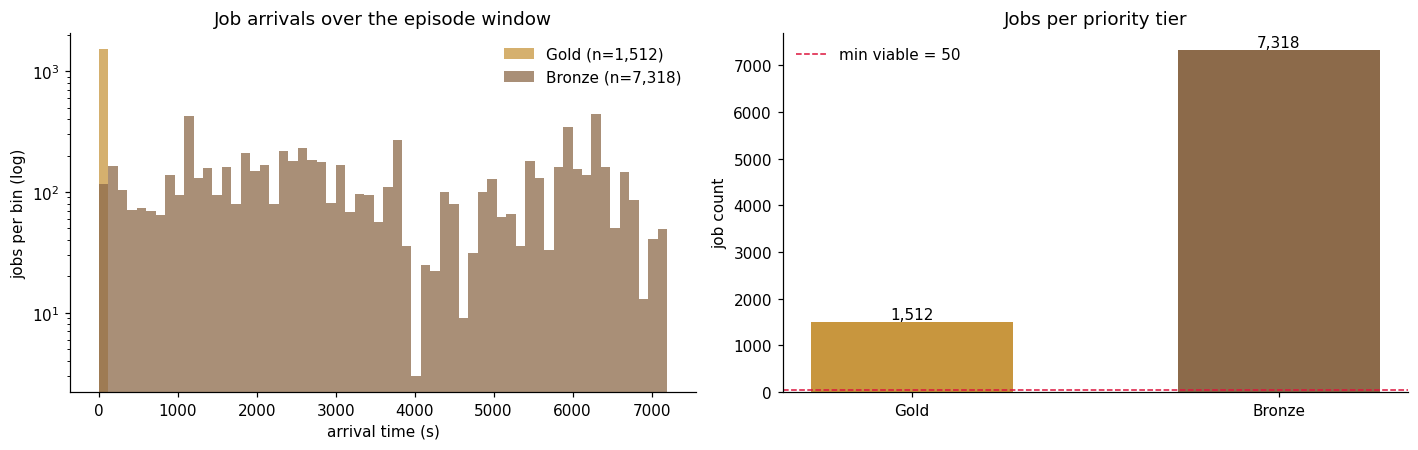

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# --- 1. Arrival-time histogram, per tier -------------------------------------------
ax = axes[0]
for tier, colour in [(TIER_ONLINE, "#C8963E"), (TIER_BATCH, "#8C6A4A")]:
    sub = jobs.loc[jobs["tier"] == tier, "arrival_time"]
    if len(sub):
        ax.hist(sub, bins=60, range=(TIME_WINDOW_START, WINDOW_END),
                alpha=0.75, label=f"{tier} (n={len(sub):,})", color=colour)
ax.set_yscale("log")
ax.set_xlabel("arrival time (s)")
ax.set_ylabel("jobs per bin (log)")
ax.set_title("Job arrivals over the episode window")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# --- 2. Gold vs Bronze counts -------------------------------------------------------
ax = axes[1]
counts = jobs["tier"].value_counts().reindex([TIER_ONLINE, TIER_BATCH]).fillna(0)
bars = ax.bar(counts.index.astype(str), counts.to_numpy(),
              color=["#C8963E", "#8C6A4A"], width=0.55)
for bar, value in zip(bars, counts.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, value,
            f"{int(value):,}", ha="center", va="bottom", fontsize=10)
ax.axhline(MIN_JOBS_PER_TIER, color="crimson", ls="--", lw=1,
           label=f"min viable = {MIN_JOBS_PER_TIER}")
ax.set_ylabel("job count")
ax.set_title("Jobs per priority tier")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

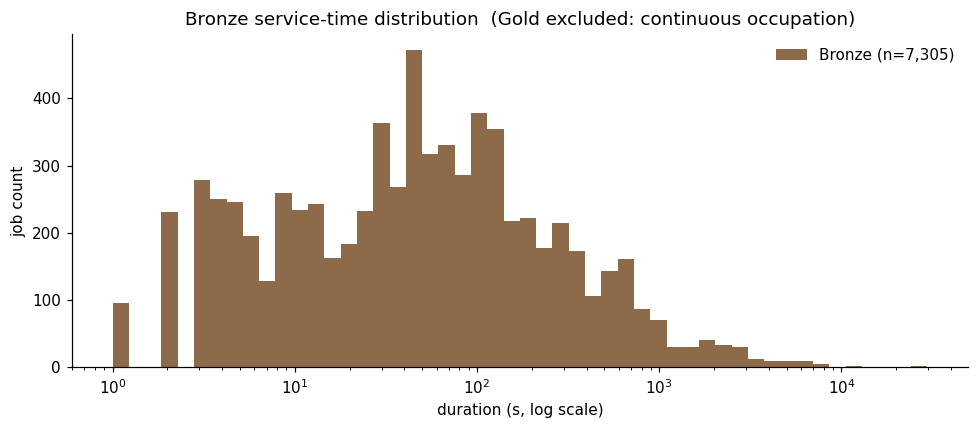

Note: 13 Bronze jobs have duration 0 s (sub-second tasks rounded down) and are omitted from this log-scale plot.
Gold jobs (1,512) have no duration by design and do not appear here.


In [49]:
# --- 3. Bronze duration distribution (log x-axis). Gold has no duration to plot. -----
fig, ax = plt.subplots(figsize=(9, 4))

positive = bronze[bronze["duration"] > 0]["duration"]
lo, hi = max(float(positive.min()), 1.0), float(positive.max())
n_bins = 50
step = (math.log10(hi) - math.log10(lo)) / n_bins
log_bins = [10 ** (math.log10(lo) + i * step) for i in range(n_bins + 1)]

ax.hist(positive, bins=log_bins, color="#8C6A4A",
        label=f"{TIER_BATCH} (n={len(positive):,})")
ax.set_xscale("log")
ax.set_xlabel("duration (s, log scale)")
ax.set_ylabel("job count")
ax.set_title("Bronze service-time distribution  (Gold excluded: continuous occupation)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

n_zero = int((bronze["duration"] == 0).sum())
print(f"Note: {n_zero:,} Bronze jobs have duration 0 s (sub-second tasks rounded down) "
      f"and are omitted from this log-scale plot.")
print(f"Gold jobs ({len(gold):,}) have no duration by design and do not appear here.")

---
## Stage 10 — Training-viability check

A tier below `MIN_JOBS_PER_TIER` (50) is too small for the DQN to learn a distinct policy
for it. If one is short: raise `TIME_WINDOW_SECONDS`, or raise `N_MACHINES` (Gold only).

In [50]:
print("TRAINING-VIABILITY CHECK")
print("=" * 62)
ok = True
for tier in [TIER_ONLINE, TIER_BATCH]:
    n = int((jobs["tier"] == tier).sum())
    if n < MIN_JOBS_PER_TIER:
        ok = False
        print(f"  [WARNING] {tier:<7s} has only {n:,} jobs "
              f"(< {MIN_JOBS_PER_TIER}) - TOO SMALL TO TRAIN ON")
    else:
        print(f"  [OK]      {tier:<7s} has {n:,} jobs (>= {MIN_JOBS_PER_TIER})")

ratio = n_bronze / max(n_gold, 1)
print(f"\n  Bronze:Gold ratio = {ratio:,.1f}:1")
if ratio > 10:
    print("  [NOTE] Heavy class imbalance - weight the reward per tier so Bronze "
          "volume does not drown out Gold SLA violations.")

# Arrival-spread diagnostic: a tier whose arrivals all land on one timestamp is an
# initial-state snapshot, not a stream, and the environment must load it as such.
print()
for tier in [TIER_ONLINE, TIER_BATCH]:
    arrivals = jobs.loc[jobs["tier"] == tier, "arrival_time"]
    spread = int(arrivals.max() - arrivals.min()) if len(arrivals) else 0
    if spread == 0:
        print(f"  [NOTE] {tier:<7s} arrivals all land at t={int(arrivals.min())} "
              f"(zero spread) - this tier is the cluster's INITIAL STATE, "
              f"not an arrival stream.")
    else:
        print(f"  [OK]      {tier:<7s} arrivals span {spread:,} s "
              f"({arrivals.nunique():,} distinct timestamps)")

print("=" * 62)
if ok:
    print("Both tiers meet the minimum. Dataset is ready for the RL environment.")
else:
    print("At least one tier is undersized - widen TIME_WINDOW_SECONDS / N_MACHINES "
          "in the config cell and re-run.")

TRAINING-VIABILITY CHECK
  [OK]      Gold    has 1,512 jobs (>= 50)
  [OK]      Bronze  has 7,318 jobs (>= 50)

  Bronze:Gold ratio = 4.8:1

  [NOTE] Gold    arrivals all land at t=0 (zero spread) - this tier is the cluster's INITIAL STATE, not an arrival stream.
  [OK]      Bronze  arrivals span 7,190 s (1,243 distinct timestamps)
Both tiers meet the minimum. Dataset is ready for the RL environment.


---
## Handoff to the RL environment

1. **Gold = initial state, continuous.** 98%+ arrive at `t = 0` (only 20 of 1,532
   arrive later, at t≈34,400-42,500 s); once placed they never release resources, so
   capacity available to Bronze only shrinks. Those 20 late arrivals are the only
   jobs where arrival order and tier priority disagree - the one place a
   priority-aware policy can differ from FCFS. Evaluate that cohort separately.
2. **Gold SLA = scheduling delay**, not completion time.
3. **Bronze = arrival stream**, releases resources at `scheduled_time + duration`. Branch
   on the `continuous` flag, not on tier.
4. **Bronze outnumbers Gold ~5:1** — weight the reward per tier or Bronze volume drowns
   out Gold SLA violations.
5. **Units:** cpu in cores, mem as a fraction of a machine's RAM (so machine capacity is
   `mem = 1.0`, `cpu = core count`).
6. **Deterministic** — no RNG anywhere, so `jobs_clean.csv` is reproducible from the config.